In [33]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# Turn off solver output
solvers.options['show_progress'] = False

class CLFCBFController:
    def __init__(self, obs_center, obs_radius, goal_pos, gamma=0.01, alpha=1.0):
        self.obs_center = np.array(obs_center)
        self.obs_radius = obs_radius
        self.goal_pos = np.array(goal_pos)
        
        self.gamma = gamma  # CBF rate (Safety aggressiveness)
        self.alpha = alpha  # CLF rate (Convergence speed)
        self.clf_penalty = 1000.0 # Penalty for violating the CLF (p)

    def get_control(self, robot_state):
        """
        Solves the CLF-CBF-QP.
        Variables to optimize: [ux, uy, delta]
        """
        x = robot_state
        
        # --- 1. Define CLF (Goal Seeking) ---
        # V(x) = ||x - x_goal||^2
        # We want: V_dot + alpha * V <= delta
        # V_dot = grad_V * u
        # Constraint: grad_V * u - delta <= -alpha * V
        
        diff_goal = x - self.goal_pos
        V = np.dot(diff_goal, diff_goal)
        grad_V = 2 * diff_goal  # Gradient of V wrt x
        
        # --- 2. Define CBF (Obstacle Avoidance) ---
        # h(x) = ||x - x_obs||^2 - r^2
        # We want: h_dot + gamma * h >= 0
        # h_dot = grad_h * u
        # Constraint: -grad_h * u <= gamma * h
        
        diff_obs = x - self.obs_center
        h = np.dot(diff_obs, diff_obs) - self.obs_radius**2
        grad_h = 2 * diff_obs
        
        # --- 3. Setup QP Matrices ---
        # Minimize: 0.5 * u^T u + 0.5 * p * delta^2
        # Vector z = [ux, uy, delta]
        
        # P Matrix (Quadratic Cost)
        # [ 1  0  0 ]
        # [ 0  1  0 ]
        # [ 0  0  p ]
        P = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        
        # q Vector (Linear Cost) -> All zeros because we minimize magnitude
        q = matrix(np.array([0.0, 0.0, 0.0]), tc='d')
        
        # G Matrix (Inequality Constraints LHS)
        # Row 1 (CLF):  grad_V_x * ux + grad_V_y * uy - 1*delta  <= -alpha * V
        # Row 2 (CBF): -grad_h_x * ux - grad_h_y * uy + 0*delta  <=  gamma * h
        
        G = matrix(np.array([
            [grad_V[0], grad_V[1], -1.0],      # CLF Constraint
            [-grad_h[0], -grad_h[1], 0.0]      # CBF Constraint (note negative signs)
        ]), tc='d')
        
        # h_qp Vector (Inequality Constraints RHS)
        h_qp = matrix(np.array([
            -self.alpha * V,   # CLF limit
            self.gamma * h     # CBF limit
        ]), tc='d')

        try:
            sol = solvers.qp(P, q, G, h_qp)
            z = np.array(sol['x']).flatten()
            u_optimal = z[:2] # Extract velocities
            slack = z[2]      # Extract slack variable (for debugging)
            return u_optimal, slack
        except ValueError:
            print("QP Infeasible! (Should not happen with slack variable)")
            return np.array([0.0, 0.0]), 0.0

def run_simulation():
    start_pos = np.array([0.0, 0.0])
    goal_pos = np.array([10.0, 9.5])
    obs_pos = np.array([5.0, 5.0])
    obs_radius = 2.0
    dt = 0.05
    steps = 500

    # Initialize Controller
    # alpha=1.0 (Convergence rate), gamma=2.0 (Safety rate)
    controller = CLFCBFController(obs_pos, obs_radius, goal_pos, gamma=4.0, alpha=1.5)
    
    current_pos = start_pos.copy()
    trajectory = [current_pos.copy()]
    
    print("Starting Simulation with CLF-CBF-QP...")
    
    for i in range(steps):
        # Note: No 'u_nominal' calculation here! 
        # The controller figures out 'u' purely from the math constraints.
        
        u_safe, slack = controller.get_control(current_pos)
        
        # Integrate Dynamics
        current_pos = current_pos + u_safe * dt
        trajectory.append(current_pos.copy())
        
        # Stop if close to goal
        if np.linalg.norm(current_pos - goal_pos) < 0.1:
            print(f"Goal Reached at step {i}!")
            break

    # Visualization
    trajectory = np.array(trajectory)
    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Path (Energy Min)')
    ax.plot(start_pos[0], start_pos[1], 'go', label='Start')
    ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')
    
    circle = plt.Circle(obs_pos, obs_radius, color='r', alpha=0.3, label='Obstacle')
    ax.add_patch(circle)
    
    ax.set_aspect('equal')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 12)
    ax.legend()
    ax.grid(True)
    ax.set_title("CLF-CBF-QP: Energy Minimization Objective")
    plt.show()


Starting Simulation with CLF-CBF-QP...
Goal Reached at step 131!


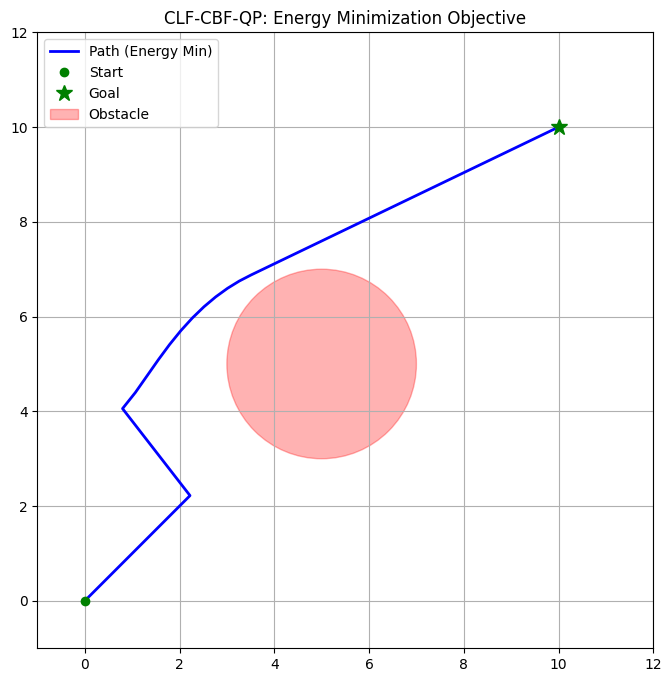

In [32]:
run_simulation()

Starting HOCBF-CLF-QP Simulation...
Goal Reached at step 167!


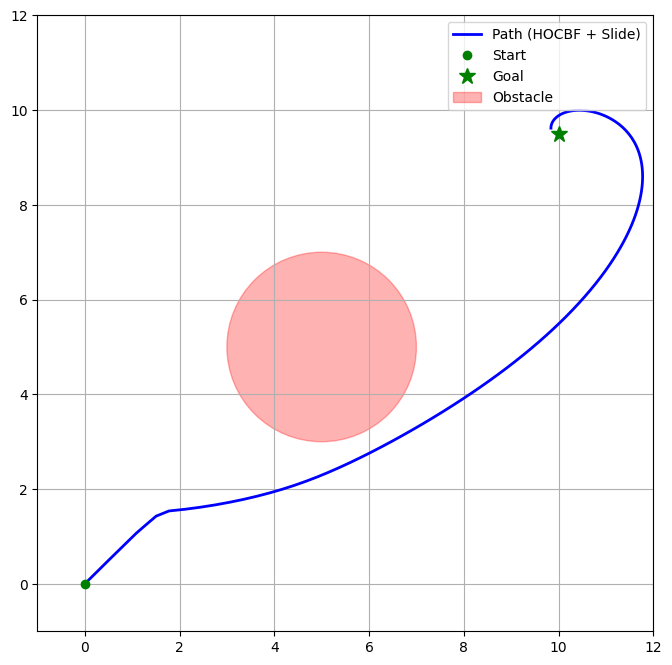

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
import scipy.linalg

# Turn off solver output
solvers.options['show_progress'] = False

class HOCBF_CLF_Controller:
    def __init__(self, obs_center, obs_radius, goal_pos):
        self.obs_center = np.array(obs_center)
        self.obs_radius = obs_radius
        self.goal_pos = np.array(goal_pos)
        
        # HOCBF alpha parameters (Tuning knobs for safety)
        self.alpha1 = 4.0  # h_dot + alpha1 * h >= 0
        self.alpha2 = 4.0  # psi_dot + alpha2 * psi >= 0
        
        # CLF parameters (Tuning knobs for goal reaching)
        self.clf_rate = 1.0 
        self.clf_penalty = 500.0  # Weight for slack variable delta
        
        # System Matrices for Double Integrator (e = [pos_err, vel])
        self.A = np.array([[0, 0, 1, 0], [0, 0, 0, 1], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.B = np.array([[0, 0], [0, 0], [1, 0], [0, 1]])
        
        # Solve Riccati equation for optimal Lyapunov Matrix P
        Q = np.eye(4) * 2.0
        R = np.eye(2) * 1.0
        self.P = scipy.linalg.solve_continuous_are(self.A, self.B, Q, R)

    def get_control(self, state):
        """
        state: [px, py, vx, vy]
        Returns: u_opt (acceleration [ax, ay]), slack (delta)
        """
        p = state[:2]
        v = state[2:]
        
        # --- 1. Define h(x) and HOCBF constraints ---
        diff = p - self.obs_center
        h = np.dot(diff, diff) - self.obs_radius**2
        grad_h_p = 2 * diff
        h_dot = np.dot(grad_h_p, v)
        
        # psi = h_dot + alpha1 * h
        psi = h_dot + self.alpha1 * h
        
        # Lf_psi = v.T * Hessian_h * v + alpha1 * h_dot
        # For circle, Hessian is 2*I
        Lf_psi = 2 * np.dot(v, v) + self.alpha1 * h_dot
        Lg_psi = grad_h_p # Term multiplying control u
        
        # --- 2. Tangential Slide Logic ---
        # Normalize vectors to check if we are heading head-on
        norm_v = v / (np.linalg.norm(v) + 1e-6)
        norm_grad = grad_h_p / (np.linalg.norm(grad_h_p) + 1e-6)
        
        # Dot product ~ -1 means moving directly into the obstacle
        # Dot product ~ 0 means moving perpendicular to gradient
        dot_product = np.dot(norm_v, norm_grad)
        
        # u_ref will guide the objective function
        u_ref = np.zeros(2)
        
        # --- NEW: Filled Slide Logic ---
        # If close (h < 1.0) and heading into or perpendicular to obstacle
        if h < 1.0 and dot_product < 0.2:
            # Calculate the two perpendicular tangents to the circle
            t1 = np.array([-norm_grad[1], norm_grad[0]])
            t2 = np.array([norm_grad[1], -norm_grad[0]])
            
            # Choose the tangent that aligns with current velocity
            slide_dir = t1 if np.dot(t1, norm_v) > np.dot(t2, norm_v) else t2
            
            # Set u_ref to a high-magnitude acceleration along that tangent
            u_ref = 5.0 * slide_dir
        
        # --- 3. CLF Formulation ---
        e = np.hstack((p - self.goal_pos, v))
        V = e.dot(self.P).dot(e)
        grad_V_e = 2 * e.dot(self.P)
        
        Lf_V = grad_V_e.dot(self.A).dot(e)
        Lg_V = grad_V_e.dot(self.B)
        
        # --- 4. Setup QP ---
        k = 20
        
        # P Matrix: [ k 0 0; 0 k 0; 0 0 penalty ]
        P_qp = matrix(np.diag([k, k, self.clf_penalty]), tc='d')
        
        # q Vector (Expansion of 0.5 * k * ||u - u_ref||^2)
        q_qp = matrix(np.array([-k * u_ref[0], -k * u_ref[1], 0.0]), tc='d')
        
        # Constraints:
        # CLF: Lg_V * u - delta <= -Lf_V - lambda * V
        # CBF: -Lg_psi * u       <= Lf_psi + alpha2 * psi
        G = matrix(np.array([
            [Lg_V[0], Lg_V[1], -1.0],      # CLF Row
            [-Lg_psi[0], -Lg_psi[1], 0.0]  # CBF Row
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.clf_rate * V - Lf_V,
            Lf_psi + self.alpha2 * psi
        ]), tc='d')

        try:
            sol = solvers.qp(P_qp, q_qp, G, h_qp)
            z = np.array(sol['x']).flatten()
            return z[:2], z[2]
        except ValueError:
            # Emergency brake
            return -2.0 * v, 0.0

def run_simulation():
    start_state = np.array([0.0, 0.0, 3.0, 3.0]) # [px, py, vx, vy]
    goal_pos = np.array([10.0, 9.5])
    obs_pos = np.array([5.0, 5.0])
    obs_radius = 2.0
    dt = 0.05
    steps = 400

    controller = HOCBF_CLF_Controller(obs_pos, obs_radius, goal_pos)
    
    state = start_state.copy()
    trajectory = [state[:2].copy()]
    
    print("Starting HOCBF-CLF-QP Simulation...")
    for i in range(steps):
        u_safe, slack = controller.get_control(state)
        
        # Double Integrator Physics Integration
        state[:2] += state[2:] * dt + 0.5 * u_safe * dt**2
        state[2:] += u_safe * dt
        
        trajectory.append(state[:2].copy())
        
        if np.linalg.norm(state[:2] - goal_pos) < 0.2 and np.linalg.norm(state[2:]) < 0.2:
            print(f"Goal Reached at step {i}!")
            break

    # Visualization
    trajectory = np.array(trajectory)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Path (HOCBF + Slide)')
    ax.plot(start_state[0], start_state[1], 'go', label='Start')
    ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')
    circle = plt.Circle(obs_pos, obs_radius, color='r', alpha=0.3, label='Obstacle')
    ax.add_patch(circle)
    ax.set_aspect('equal')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 12)
    ax.legend()
    ax.grid(True)
    plt.show()

run_simulation()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from cvxopt import matrix, solvers

# 1. Turn off CVXOPT solver verbose output
solvers.options['show_progress'] = False

# --- HELPER: Smooth Rectangle Barrier ---
def get_smooth_rectangle_barrier(robot_pos, rect_config, rho=20.0):
    """
    Calculates h(x) and grad_h(x) for a smoothed rectangular obstacle.
    Using Log-Sum-Exp to combine 4 linear constraints into 1 smooth function.
    """
    x, y = robot_pos
    
    x_min, x_max = rect_config['x_min'], rect_config['x_max']
    y_min, y_max = rect_config['y_min'], rect_config['y_max']

    # Signed distances to walls (Positive = Safe/Outside)
    h1 = x - x_max      # Right side
    h2 = x_min - x      # Left side
    h3 = y - y_max      # Top side
    h4 = y_min - y      # Bottom side
    
    h_vals = np.array([h1, h2, h3, h4])
    
    # SoftMax Formulation
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    
    # 1. Barrier Value h(x)
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    # 2. Gradient grad_h(x)
    normals = np.array([
        [1.0, 0.0],   # Normal for x > x_max
        [-1.0, 0.0],  # Normal for x < x_min
        [0.0, 1.0],   # Normal for y > y_max
        [0.0, -1.0]   # Normal for y < y_min
    ])
    
    weights = exps / sum_exps
    
    grad_h = np.zeros(2)
    for i in range(4):
        grad_h += weights[i] * normals[i]
        
    return h_val, grad_h

# --- CONTROLLER CLASS ---
class CLFCBF_Rect_Controller:
    def __init__(self, rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.gamma = gamma          # Safety (CBF) decay rate
        self.alpha = alpha          # Goal (CLF) convergence rate
        self.clf_penalty = clf_penalty  # Cost of relaxing the goal (Slack p)

    def get_control(self, robot_state):
        x = robot_state
        
        # --- 1. Calculate Reference Velocity (u_ref) ---
        # This is the "Magnet" behavior we put in the Objective
        Kp = 2.0
        u_ref = Kp * (self.goal_pos - x)
        
        # Speed Limit
        max_speed = 4.0
        if np.linalg.norm(u_ref) > max_speed:
            u_ref = u_ref / np.linalg.norm(u_ref) * max_speed

        # --- 2. CLF Terms (Goal Constraint) ---
        # V(x) = ||x - goal||^2
        diff_goal = x - self.goal_pos
        V = np.dot(diff_goal, diff_goal)
        grad_V = 2 * diff_goal

        # --- 3. CBF Terms (Safety Constraint) ---
        h, grad_h = get_smooth_rectangle_barrier(x, self.rect_config, rho=10.0)

        # --- 4. QP Formulation ---
        # Variables: z = [ux, uy, delta]
        
        # Objective: Min 0.5 * ||u - u_ref||^2 + 0.5 * p * delta^2
        # Expanded: 0.5*u'u - u_ref'u + ...
        
        # P Matrix: [1, 0, 0; 0, 1, 0; 0, 0, p]
        P = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        
        # q Vector: [-u_ref_x, -u_ref_y, 0]
        q = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        # Constraints Matrix G and vector h_qp
        # Row 1 (CLF): grad_V*u - delta <= -alpha*V
        # Row 2 (CBF): -grad_h*u        <= gamma*h
        
        G = matrix(np.array([
            [grad_V[0], grad_V[1], -1.0],      # CLF Constraint (with slack)
            [-grad_h[0], -grad_h[1], 0.0]      # CBF Constraint (Hard safety)
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.alpha * V,   # CLF RHS
            self.gamma * h     # CBF RHS
        ]), tc='d')

        # Solve QP
        try:
            sol = solvers.qp(P, q, G, h_qp)
            z = np.array(sol['x']).flatten()
            u_opt = z[:2]
            slack = z[2]
            return u_opt, slack, h
        except ValueError:
            # If solver fails, return zero velocity
            return np.array([0.0, 0.0]), 0.0, h

# --- SIMULATION LOOP ---
def run_simulation():
    # Setup Scenario
    start_pos = np.array([0.0, 5.0])    # Left
    goal_pos = np.array([12.0, 6.0])    # Right
    
    # Wall in the middle
    rect_config = {'x_min': 5.0, 'x_max': 7.0, 'y_min': 2.0, 'y_max': 8.0}
    
    # Initialize Controller
    controller = CLFCBF_Rect_Controller(
        rect_config, 
        goal_pos, 
        gamma=5.0,     # Allow getting reasonably close to wall
        alpha=2.0,     # Force stronger convergence to goal
        clf_penalty=1000.0 # High penalty for relaxing goal
    )
    
    dt = 0.05
    steps = 400
    
    current_pos = start_pos.copy()
    trajectory = [current_pos.copy()]
    slack_history = []
    
    print("Starting Simulation (CLF-CBF-QP)...")
    
    for i in range(steps):
        # Get Control
        u_safe, slack, h_val = controller.get_control(current_pos)
        
        # Integrate Dynamics
        current_pos = current_pos + u_safe * dt
        
        trajectory.append(current_pos.copy())
        slack_history.append(slack)
        
        # Goal Check
        if np.linalg.norm(current_pos - goal_pos) < 0.1:
            print(f"Goal Reached at step {i}!")
            break

    # --- VISUALIZATION ---
    trajectory = np.array(trajectory)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Trajectory
    width = rect_config['x_max'] - rect_config['x_min']
    height = rect_config['y_max'] - rect_config['y_min']
    rect_patch = patches.Rectangle(
        (rect_config['x_min'], rect_config['y_min']), 
        width, height, 
        linewidth=2, edgecolor='r', facecolor='salmon', alpha=0.5, label='Obstacle'
    )
    ax1.add_patch(rect_patch)
    
    ax1.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Robot Path')
    ax1.plot(start_pos[0], start_pos[1], 'go', markersize=10, label='Start')
    ax1.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
    
    ax1.set_aspect('equal')
    ax1.set_xlim(-1, 14)
    ax1.set_ylim(0, 10)
    ax1.legend()
    ax1.grid(True)
    ax1.set_title("CLF-CBF Trajectory")

    # Plot 2: Slack Variable (Delta)
    ax2.plot(slack_history, 'r-', label='Slack (Delta)')
    ax2.set_title("CLF Relaxation (Slack)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Delta Magnitude")
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


Starting Simulation (CLF-CBF-QP)...
Goal Reached at step 63!


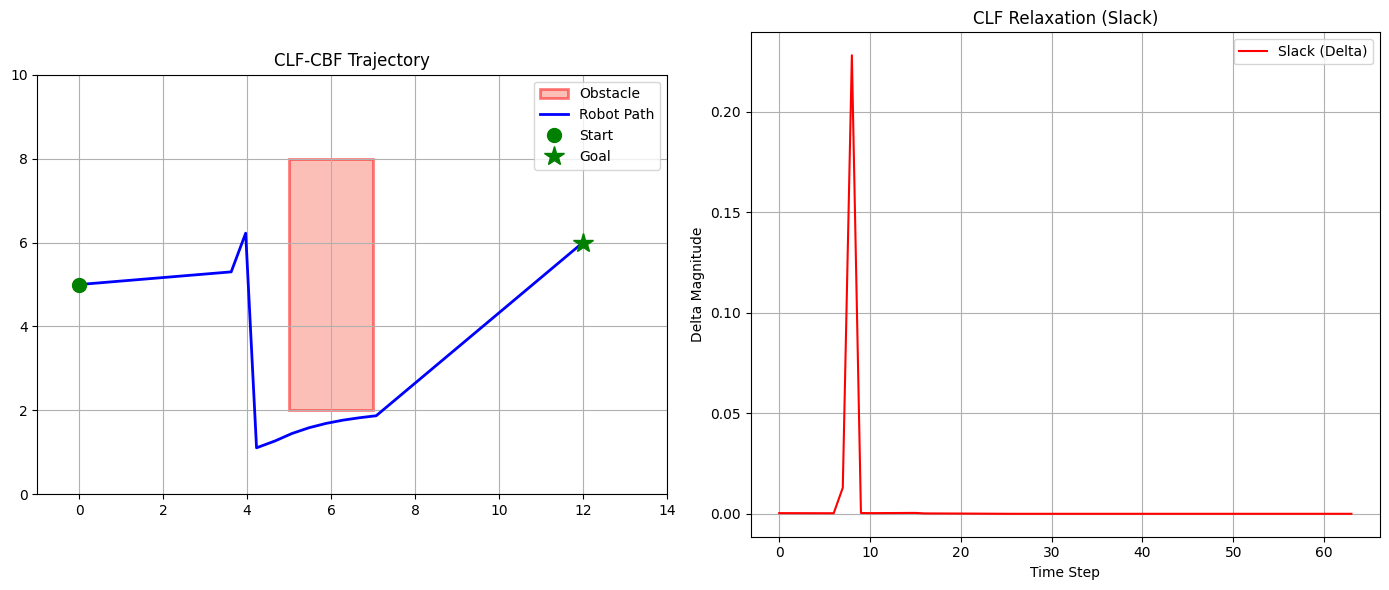

In [22]:
run_simulation()

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from cvxopt import matrix, solvers

# 1. Turn off CVXOPT solver verbose output
solvers.options['show_progress'] = False

# --- HELPER: Smooth Rectangle Barrier ---
def get_smooth_rectangle_barrier(robot_pos, rect_config, rho=20.0):
    """
    Calculates h(x) and grad_h(x) for a smoothed rectangular obstacle.
    Using Log-Sum-Exp to combine 4 linear constraints into 1 smooth function.
    """
    x, y = robot_pos
    
    x_min, x_max = rect_config['x_min'], rect_config['x_max']
    y_min, y_max = rect_config['y_min'], rect_config['y_max']

    # Signed distances to walls (Positive = Safe/Outside)
    h1 = x - x_max      # Right side
    h2 = x_min - x      # Left side
    h3 = y - y_max      # Top side
    h4 = y_min - y      # Bottom side
    
    h_vals = np.array([h1, h2, h3, h4])
    
    # SoftMax Formulation
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    
    # 1. Barrier Value h(x)
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    # 2. Gradient grad_h(x)
    normals = np.array([
        [1.0, 0.0],   # Normal for x > x_max
        [-1.0, 0.0],  # Normal for x < x_min
        [0.0, 1.0],   # Normal for y > y_max
        [0.0, -1.0]   # Normal for y < y_min
    ])
    
    weights = exps / sum_exps
    
    grad_h = np.zeros(2)
    for i in range(4):
        grad_h += weights[i] * normals[i]
        
    return h_val, grad_h

# --- CONTROLLER CLASS ---
class CLFCBF_Rect_Controller:
    def __init__(self, rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.gamma = gamma
        self.alpha = alpha
        self.clf_penalty = clf_penalty
        self.prev_u = np.array([1.0, 0.0]) # Initialize with a default direction

    def get_control(self, robot_state):
        x = robot_state
        
        # 1. Calculate Nominal Control (u_ref / Magnet)
        Kp = 2.0
        u_ref = Kp * (self.goal_pos - x)
        
        # 2. Get Barrier Info
        h, grad_h = get_smooth_rectangle_barrier(x, self.rect_config, rho=20.0)
        
        # --- NEW LOGIC: Perpendicular Check & Tangential Slide ---
        # Normalize vectors to check alignment
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        norm_u_ref = u_ref / (np.linalg.norm(u_ref) + 1e-6)
        
        # Dot product ~ 0 means perpendicular
        dot_product = np.dot(norm_u_ref, norm_grad)
        
        # Threshold for "perpendicular enough" (e.g., within 5-10 degrees)
        if h < 0.5 and abs(dot_product) < 0.15:
            # 1. Calculate the two possible perpendicular directions (Tangents)
            # For a 2D vector [nx, ny], the perpendiculars are [-ny, nx] and [ny, -nx]
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            
            # 2. Choose the one closer to our previous movement direction
            if np.dot(tangent1, self.prev_u) > np.dot(tangent2, self.prev_u):
                u_ref = tangent1 * np.linalg.norm(u_ref)
            else:
                u_ref = tangent2 * np.linalg.norm(u_ref)
        
        # --- Standard CLF-CBF QP from here ---
        # (Same as before, but now u_ref has been modified if near obstacle)
        
        diff_goal = x - self.goal_pos
        V = np.dot(diff_goal, diff_goal)
        grad_V = 2 * diff_goal

        P = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        q = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [grad_V[0], grad_V[1], -1.0],
            [-grad_h[0], -grad_h[1], 0.0]
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.alpha * V,
            self.gamma * h
        ]), tc='d')

        try:
            sol = solvers.qp(P, q, G, h_qp)
            z = np.array(sol['x']).flatten()
            u_opt = z[:2]
            self.prev_u = u_opt # Store for next step
            return u_opt, z[2], h
        except ValueError:
            return np.array([0.0, 0.0]), 0.0, h

# --- SIMULATION LOOP ---
def run_simulation():
    # Setup Scenario
    start_pos = np.array([0.0, 5.0])    # Left
    goal_pos = np.array([12.0, 6.0])    # Right
    
    # Wall in the middle
    rect_config = {'x_min': 5.0, 'x_max': 7.0, 'y_min': 2.0, 'y_max': 8.0}
    
    # Initialize Controller
    controller = CLFCBF_Rect_Controller(
        rect_config, 
        goal_pos, 
        gamma=5.0,     # Allow getting reasonably close to wall
        alpha=2.0,     # Force stronger convergence to goal
        clf_penalty=1000.0 # High penalty for relaxing goal
    )
    
    dt = 0.05
    steps = 400
    
    current_pos = start_pos.copy()
    trajectory = [current_pos.copy()]
    slack_history = []
    
    print("Starting Simulation (CLF-CBF-QP)...")
    
    for i in range(steps):
        # Get Control
        u_safe, slack, h_val = controller.get_control(current_pos)
        
        # Integrate Dynamics
        current_pos = current_pos + u_safe * dt
        
        trajectory.append(current_pos.copy())
        slack_history.append(slack)
        
        # Goal Check
        if np.linalg.norm(current_pos - goal_pos) < 0.1:
            print(f"Goal Reached at step {i}!")
            break

    # --- VISUALIZATION ---
    trajectory = np.array(trajectory)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Trajectory
    width = rect_config['x_max'] - rect_config['x_min']
    height = rect_config['y_max'] - rect_config['y_min']
    rect_patch = patches.Rectangle(
        (rect_config['x_min'], rect_config['y_min']), 
        width, height, 
        linewidth=2, edgecolor='r', facecolor='salmon', alpha=0.5, label='Obstacle'
    )
    ax1.add_patch(rect_patch)
    
    ax1.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Robot Path')
    ax1.plot(start_pos[0], start_pos[1], 'go', markersize=10, label='Start')
    ax1.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
    
    ax1.set_aspect('equal')
    ax1.set_xlim(-1, 14)
    ax1.set_ylim(0, 10)
    ax1.legend()
    ax1.grid(True)
    ax1.set_title("CLF-CBF Trajectory")

    # Plot 2: Slack Variable (Delta)
    ax2.plot(slack_history, 'r-', label='Slack (Delta)')
    ax2.set_title("CLF Relaxation (Slack)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Delta Magnitude")
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


Starting Simulation (CLF-CBF-QP)...
Goal Reached at step 48!


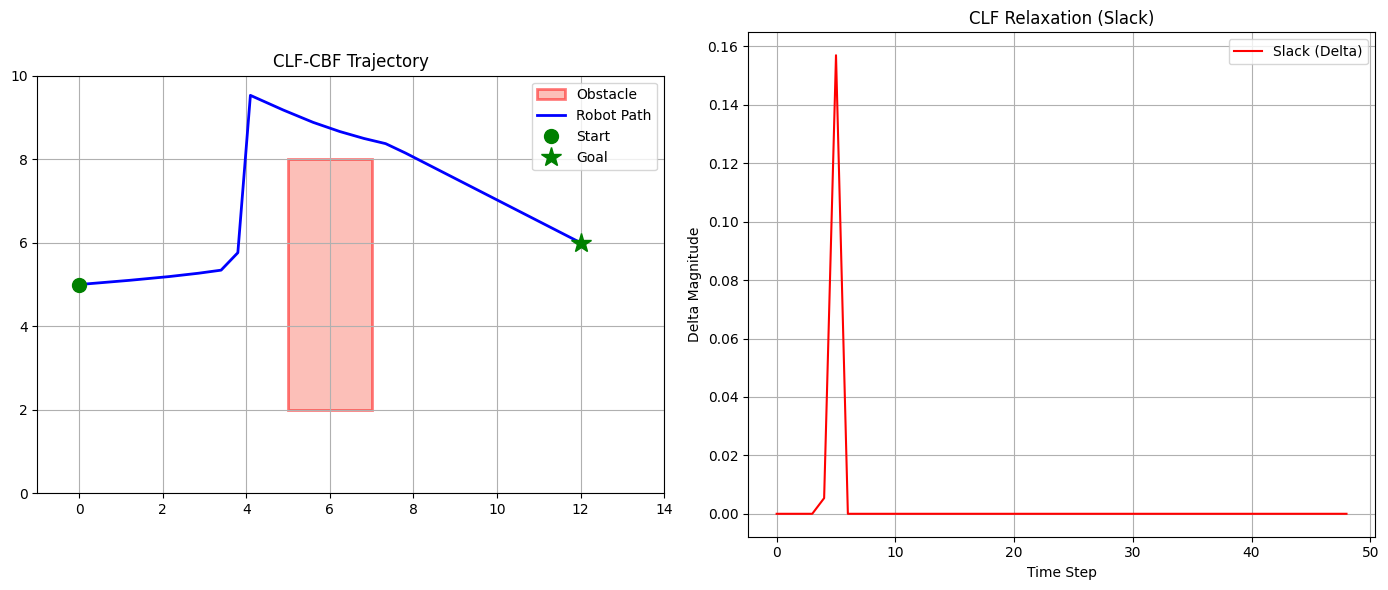

In [48]:
run_simulation()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from cvxopt import matrix, solvers
import scipy.linalg

# Turn off solver verbose output
solvers.options['show_progress'] = False

# --- HELPER 1: Smooth Rectangle Barrier ---
def get_smooth_rect_h_grad(p, config, rho=8.0):
    """ Returns h(p) and grad_h(p) for smooth rectangle using Log-Sum-Exp. """
    x, y = p
    h1 = x - config['x_max'] # Right
    h2 = config['x_min'] - x # Left
    h3 = y - config['y_max'] # Top
    h4 = config['y_min'] - y # Bottom
    h_vals = np.array([h1, h2, h3, h4])
    
    # SoftMax 
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    
    # Value
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    # Gradient
    normals = np.array([[1,0], [-1,0], [0,1], [0,-1]])
    weights = exps / sum_exps
    grad_h = np.sum(weights[:, None] * normals, axis=0)
    
    return h_val, grad_h

# --- HELPER 2: Generate Valid CLF Matrix (P) ---
def get_lqr_P_matrix():
    """
    Solves Continuous ARE to find P for the Double Integrator system.
    System: dx = Ax + Bu
    """
    # State: [px, py, vx, vy]
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ])
    B = np.array([
        [0, 0],
        [0, 0],
        [1, 0],
        [0, 1]
    ])
    # Cost Matrices
    Q = np.eye(4) * 1.0  # Penalty on state error
    R = np.eye(2) * 1.0  # Penalty on control effort
    
    # Solve Riccati Equation: A.T*P + P*A - P*B*R_inv*B.T*P + Q = 0
    P = scipy.linalg.solve_continuous_are(A, B, Q, R)
    return P, A, B

# --- CONTROLLER CLASS ---
class HOCBF_CLF_Rect_Controller:
    def __init__(self, rect_config, goal_pos):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.P, self.A, self.B = get_lqr_P_matrix()
        
        # Tuning
        self.clf_rate = 1.0       
        self.clf_penalty = 400.0  
        self.hocbf_alpha1 = 5.0   
        self.hocbf_alpha2 = 5.0   
        
    def get_control(self, state):
        p = state[:2]
        v = state[2:]
        
        # --- 1. Barrier Terms ---
        h, grad_h = get_smooth_rect_h_grad(p, self.rect_config, rho=8.0) # Sharp rho helps
        h_dot = np.dot(grad_h, v)

        # --- NEW LOGIC: Tangential Redirection ---
        # Normalize for geometry check
        norm_v = v / (np.linalg.norm(v) + 1e-6)
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        
        # If we are close (h < 1.0) and moving into the wall (dot product < 0.2)
        if h < 1.0 and np.dot(norm_v, norm_grad) < 0.2:
            # Calculate two possible sliding directions (perpendicular to normal)
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            
            # Choose the one that aligns with current velocity to maintain momentum
            slide_dir = tangent1 if np.dot(tangent1, norm_v) > np.dot(tangent2, norm_v) else tangent2
            
            # We inject this 'slide' into the QP by setting a reference acceleration
            # that 'wants' to move parallel to the wall
            u_ref = 5.0 * slide_dir # Magnitude of 'push' along the wall
        else:
            # Otherwise, use standard Energy Minimization (u_ref = 0)
            u_ref = np.zeros(2)

        # --- 2. CLF & HOCBF Constraints (Same as your code) ---
        e = np.hstack((p - self.goal_pos, v))
        V = e.dot(self.P).dot(e)
        grad_V_e = 2 * e.dot(self.P)
        Lf_V = grad_V_e.dot(self.A).dot(e)
        Lg_V = grad_V_e.dot(self.B)

        dt_fake = 0.001
        p_lookahead = p + v * dt_fake
        _, grad_h_next = get_smooth_rect_h_grad(p_lookahead, self.rect_config)
        grad_h_dot_approx = (grad_h_next - grad_h) / dt_fake
        
        psi1 = h_dot + self.hocbf_alpha1 * h
        Lf_psi = np.dot(grad_h_dot_approx, v) + self.hocbf_alpha1 * h_dot
        Lg_psi = grad_h
        
        # --- 3. QP Formulation ---
        P_qp = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        # We track our slide_dir reference if it was calculated
        q_qp = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [Lg_V[0], Lg_V[1], -1.0],      
            [-Lg_psi[0], -Lg_psi[1], 0.0]  
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.clf_rate * V - Lf_V,                     
            Lf_psi + self.hocbf_alpha2 * psi1              
        ]), tc='d')

        try:
            sol = solvers.qp(P_qp, q_qp, G, h_qp)
            z = np.array(sol['x']).flatten()
            return z[:2], z[2], V
        except ValueError:
            return -3.0 * v, 0.0, V

# --- SIMULATION ---
def run_simulation():
    # Setup
    start_state = np.array([0.0, 5.0, 4.0, 0.0]) # [px, py, vx, vy] - High initial speed!
    goal_pos = np.array([12.0, 6.0])
    
    # Obstacle
    rect = {'x_min': 5.0, 'x_max': 7.0, 'y_min': 2.0, 'y_max': 8.0}
    
    controller = HOCBF_CLF_Rect_Controller(rect, goal_pos)
    
    dt = 0.05
    steps = 250
    state = start_state.copy()
    
    traj = [state[:2].copy()]
    slack_log = []
    
    print("Running HOCBF-CLF-QP (Rectangle)...")
    
    for i in range(steps):
        u_safe, slack, V_val = controller.get_control(state)
        
        # Double Integrator Dynamics
        state[:2] += state[2:] * dt + 0.5 * u_safe * dt**2
        state[2:] += u_safe * dt
        
        traj.append(state[:2].copy())
        slack_log.append(slack)
        
        if np.linalg.norm(state[:2] - goal_pos) < 0.2 and np.linalg.norm(state[2:]) < 0.5:
            print(f"Goal Reached at step {i}!")
            break

    # --- PLOTTING ---
    traj = np.array(traj)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Trajectory
    width = rect['x_max'] - rect['x_min']
    height = rect['y_max'] - rect['y_min']
    rect_patch = patches.Rectangle(
        (rect['x_min'], rect['y_min']), width, height, 
        color='salmon', alpha=0.5, label='Obstacle'
    )
    ax1.add_patch(rect_patch)
    
    ax1.plot(traj[:, 0], traj[:, 1], 'b-', linewidth=2, label='Trajectory')
    ax1.plot(start_state[0], start_state[1], 'go', label='Start')
    ax1.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')
    ax1.set_title("HOCBF")
    ax1.set_xlim(-1, 14)
    ax1.set_ylim(0, 10)
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Slack
    ax2.plot(slack_log, 'r-')
    ax2.set_title("CLF Slack Variable (Delta)")
    ax2.set_xlabel("Step")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

Running HOCBF-CLF-QP (Rectangle)...
Goal Reached at step 172!


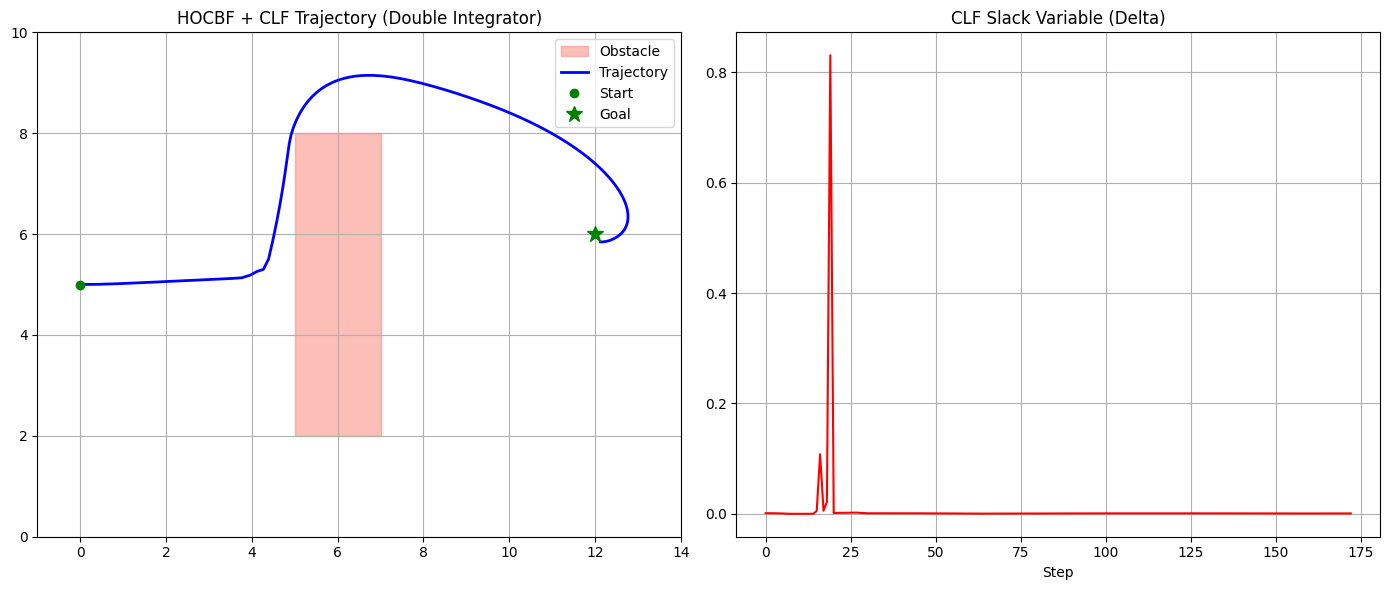

In [60]:
run_simulation()

Running CLF-CBF-QP (Single Integrator)...
CBF Goal Reached at step 48!
Running HOCBF-CLF-QP (Double Integrator)...
HOCBF Goal Reached at step 172!


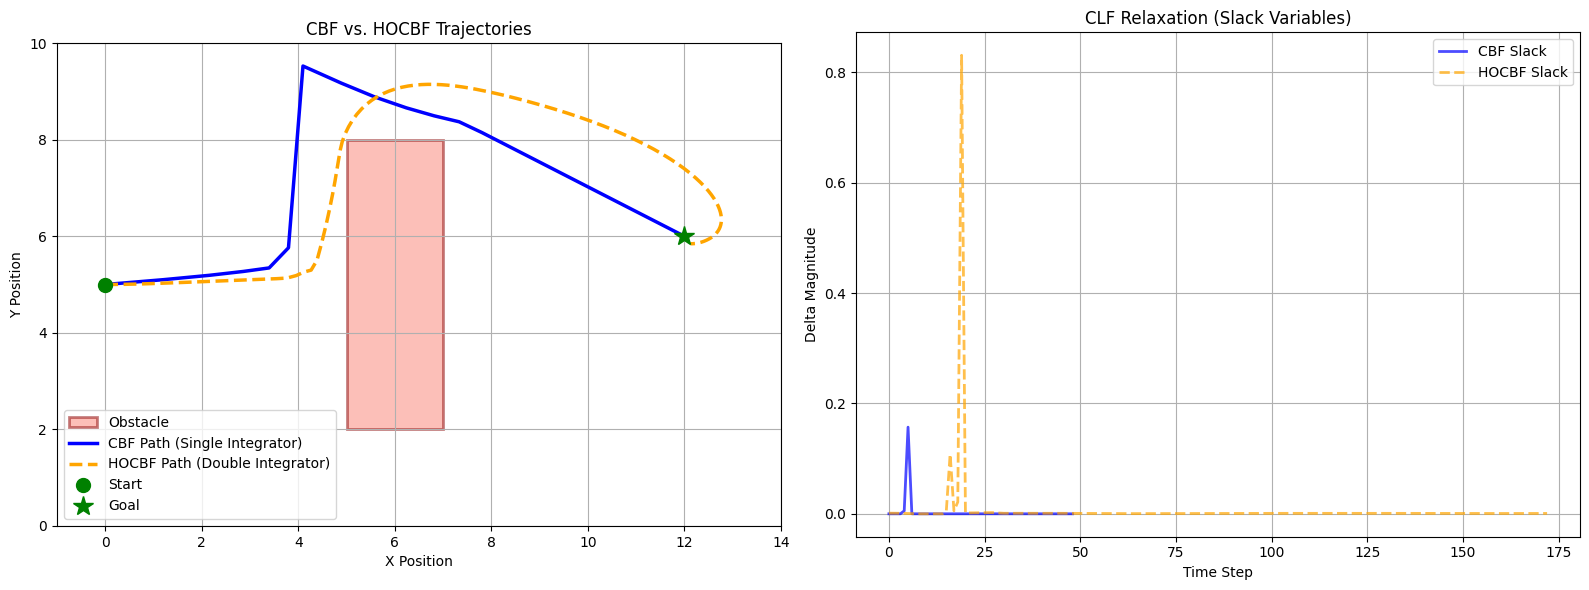

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from cvxopt import matrix, solvers
import scipy.linalg

# Turn off CVXOPT solver verbose output
solvers.options['show_progress'] = False

# ==========================================
# --- 1. PLAIN CBF (SINGLE INTEGRATOR) ---
# ==========================================

def get_smooth_rectangle_barrier(robot_pos, rect_config, rho=20.0):
    x, y = robot_pos
    x_min, x_max = rect_config['x_min'], rect_config['x_max']
    y_min, y_max = rect_config['y_min'], rect_config['y_max']

    h1 = x - x_max      
    h2 = x_min - x      
    h3 = y - y_max      
    h4 = y_min - y      
    
    h_vals = np.array([h1, h2, h3, h4])
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    normals = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
    weights = exps / sum_exps
    
    grad_h = np.zeros(2)
    for i in range(4):
        grad_h += weights[i] * normals[i]
        
    return h_val, grad_h

class CLFCBF_Rect_Controller:
    def __init__(self, rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.gamma = gamma
        self.alpha = alpha
        self.clf_penalty = clf_penalty
        self.prev_u = np.array([1.0, 0.0]) 

    def get_control(self, robot_state):
        x = robot_state
        Kp = 2.0
        u_ref = Kp * (self.goal_pos - x)
        
        h, grad_h = get_smooth_rectangle_barrier(x, self.rect_config, rho=20.0)
        
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        norm_u_ref = u_ref / (np.linalg.norm(u_ref) + 1e-6)
        dot_product = np.dot(norm_u_ref, norm_grad)
        
        if h < 0.5 and abs(dot_product) < 0.15:
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            if np.dot(tangent1, self.prev_u) > np.dot(tangent2, self.prev_u):
                u_ref = tangent1 * np.linalg.norm(u_ref)
            else:
                u_ref = tangent2 * np.linalg.norm(u_ref)
        
        diff_goal = x - self.goal_pos
        V = np.dot(diff_goal, diff_goal)
        grad_V = 2 * diff_goal

        P = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        q = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [grad_V[0], grad_V[1], -1.0],
            [-grad_h[0], -grad_h[1], 0.0]
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.alpha * V,
            self.gamma * h
        ]), tc='d')

        try:
            sol = solvers.qp(P, q, G, h_qp)
            z = np.array(sol['x']).flatten()
            u_opt = z[:2]
            self.prev_u = u_opt 
            return u_opt, z[2], h
        except ValueError:
            return np.array([0.0, 0.0]), 0.0, h


# ==========================================
# --- 2. HOCBF (DOUBLE INTEGRATOR) ---
# ==========================================

def get_smooth_rect_h_grad(p, config, rho=8.0):
    x, y = p
    h1 = x - config['x_max'] 
    h2 = config['x_min'] - x 
    h3 = y - config['y_max'] 
    h4 = config['y_min'] - y 
    h_vals = np.array([h1, h2, h3, h4])
    
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    normals = np.array([[1,0], [-1,0], [0,1], [0,-1]])
    weights = exps / sum_exps
    grad_h = np.sum(weights[:, None] * normals, axis=0)
    
    return h_val, grad_h

def get_lqr_P_matrix():
    A = np.array([[0, 0, 1, 0], [0, 0, 0, 1], [0, 0, 0, 0], [0, 0, 0, 0]])
    B = np.array([[0, 0], [0, 0], [1, 0], [0, 1]])
    Q = np.eye(4) * 1.0  
    R = np.eye(2) * 1.0  
    
    P = scipy.linalg.solve_continuous_are(A, B, Q, R)
    return P, A, B

class HOCBF_CLF_Rect_Controller:
    def __init__(self, rect_config, goal_pos):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.P, self.A, self.B = get_lqr_P_matrix()
        
        self.clf_rate = 1.0       
        self.clf_penalty = 400.0  
        self.hocbf_alpha1 = 5.0   
        self.hocbf_alpha2 = 5.0   
        
    def get_control(self, state):
        p = state[:2]
        v = state[2:]
        
        h, grad_h = get_smooth_rect_h_grad(p, self.rect_config, rho=8.0) 
        h_dot = np.dot(grad_h, v)

        norm_v = v / (np.linalg.norm(v) + 1e-6)
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        
        if h < 1.0 and np.dot(norm_v, norm_grad) < 0.2:
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            slide_dir = tangent1 if np.dot(tangent1, norm_v) > np.dot(tangent2, norm_v) else tangent2
            u_ref = 5.0 * slide_dir 
        else:
            u_ref = np.zeros(2)

        e = np.hstack((p - self.goal_pos, v))
        V = e.dot(self.P).dot(e)
        grad_V_e = 2 * e.dot(self.P)
        Lf_V = grad_V_e.dot(self.A).dot(e)
        Lg_V = grad_V_e.dot(self.B)

        dt_fake = 0.001
        p_lookahead = p + v * dt_fake
        _, grad_h_next = get_smooth_rect_h_grad(p_lookahead, self.rect_config)
        grad_h_dot_approx = (grad_h_next - grad_h) / dt_fake
        
        psi1 = h_dot + self.hocbf_alpha1 * h
        Lf_psi = np.dot(grad_h_dot_approx, v) + self.hocbf_alpha1 * h_dot
        Lg_psi = grad_h
        
        P_qp = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        q_qp = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [Lg_V[0], Lg_V[1], -1.0],      
            [-Lg_psi[0], -Lg_psi[1], 0.0]  
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.clf_rate * V - Lf_V,                     
            Lf_psi + self.hocbf_alpha2 * psi1              
        ]), tc='d')

        try:
            sol = solvers.qp(P_qp, q_qp, G, h_qp)
            z = np.array(sol['x']).flatten()
            return z[:2], z[2], V
        except ValueError:
            return -3.0 * v, 0.0, V


# ==========================================
# --- 3. COMBINED SIMULATION & PLOTTING ---
# ==========================================

def run_combined_simulation():
    # Setup Shared Scenario
    start_pos = np.array([0.0, 5.0])
    goal_pos = np.array([12.0, 6.0])
    rect_config = {'x_min': 5.0, 'x_max': 7.0, 'y_min': 2.0, 'y_max': 8.0}
    dt = 0.05
    steps = 400
    
    # --- RUN CBF ---
    cbf_controller = CLFCBF_Rect_Controller(rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0)
    state_cbf = start_pos.copy()
    traj_cbf = [state_cbf.copy()]
    slack_cbf = []
    
    print("Running CLF-CBF-QP (Single Integrator)...")
    for i in range(steps):
        u_safe, slack, _ = cbf_controller.get_control(state_cbf)
        state_cbf = state_cbf + u_safe * dt
        traj_cbf.append(state_cbf.copy())
        slack_cbf.append(slack)
        if np.linalg.norm(state_cbf - goal_pos) < 0.1:
            print(f"CBF Goal Reached at step {i}!")
            break

    # --- RUN HOCBF ---
    hocbf_controller = HOCBF_CLF_Rect_Controller(rect_config, goal_pos)
    state_hocbf = np.array([0.0, 5.0, 4.0, 0.0]) # Includes high initial velocity
    traj_hocbf = [state_hocbf[:2].copy()]
    slack_hocbf = []
    
    print("Running HOCBF-CLF-QP (Double Integrator)...")
    for i in range(steps):
        u_safe, slack, _ = hocbf_controller.get_control(state_hocbf)
        state_hocbf[:2] += state_hocbf[2:] * dt + 0.5 * u_safe * dt**2
        state_hocbf[2:] += u_safe * dt
        traj_hocbf.append(state_hocbf[:2].copy())
        slack_hocbf.append(slack)
        if np.linalg.norm(state_hocbf[:2] - goal_pos) < 0.2 and np.linalg.norm(state_hocbf[2:]) < 0.5:
            print(f"HOCBF Goal Reached at step {i}!")
            break

    # --- VISUALIZATION ---
    traj_cbf = np.array(traj_cbf)
    traj_hocbf = np.array(traj_hocbf)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Combined Trajectories
    width = rect_config['x_max'] - rect_config['x_min']
    height = rect_config['y_max'] - rect_config['y_min']
    rect_patch = patches.Rectangle(
        (rect_config['x_min'], rect_config['y_min']), width, height, 
        linewidth=2, edgecolor='darkred', facecolor='salmon', alpha=0.5, label='Obstacle'
    )
    ax1.add_patch(rect_patch)
    
    ax1.plot(traj_cbf[:, 0], traj_cbf[:, 1], 'b-', linewidth=2.5, label='CBF Path (Single Integrator)')
    ax1.plot(traj_hocbf[:, 0], traj_hocbf[:, 1], 'orange', linewidth=2.5, linestyle='--', label='HOCBF Path (Double Integrator)')
    
    ax1.plot(start_pos[0], start_pos[1], 'go', markersize=10, label='Start')
    ax1.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
    
    ax1.set_aspect('equal')
    ax1.set_xlim(-1, 14)
    ax1.set_ylim(0, 10)
    ax1.legend(loc='lower left')
    ax1.grid(True)
    ax1.set_title("CBF vs. HOCBF Trajectories")
    ax1.set_xlabel("X Position")
    ax1.set_ylabel("Y Position")

    # Plot 2: Combined Slacks
    ax2.plot(slack_cbf, 'b-', alpha=0.7, linewidth=2, label='CBF Slack')
    ax2.plot(slack_hocbf, 'orange', alpha=0.7, linewidth=2, linestyle='--', label='HOCBF Slack')
    ax2.set_title("CLF Relaxation (Slack Variables)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Delta Magnitude")
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Execute the combined simulation
if __name__ == "__main__":
    run_combined_simulation()

Running CLF-CBF-QP (Single Integrator)...
CBF Goal Reached at step 48!
Running HOCBF-CLF-QP (Double Integrator)...
HOCBF Goal Reached at step 172!


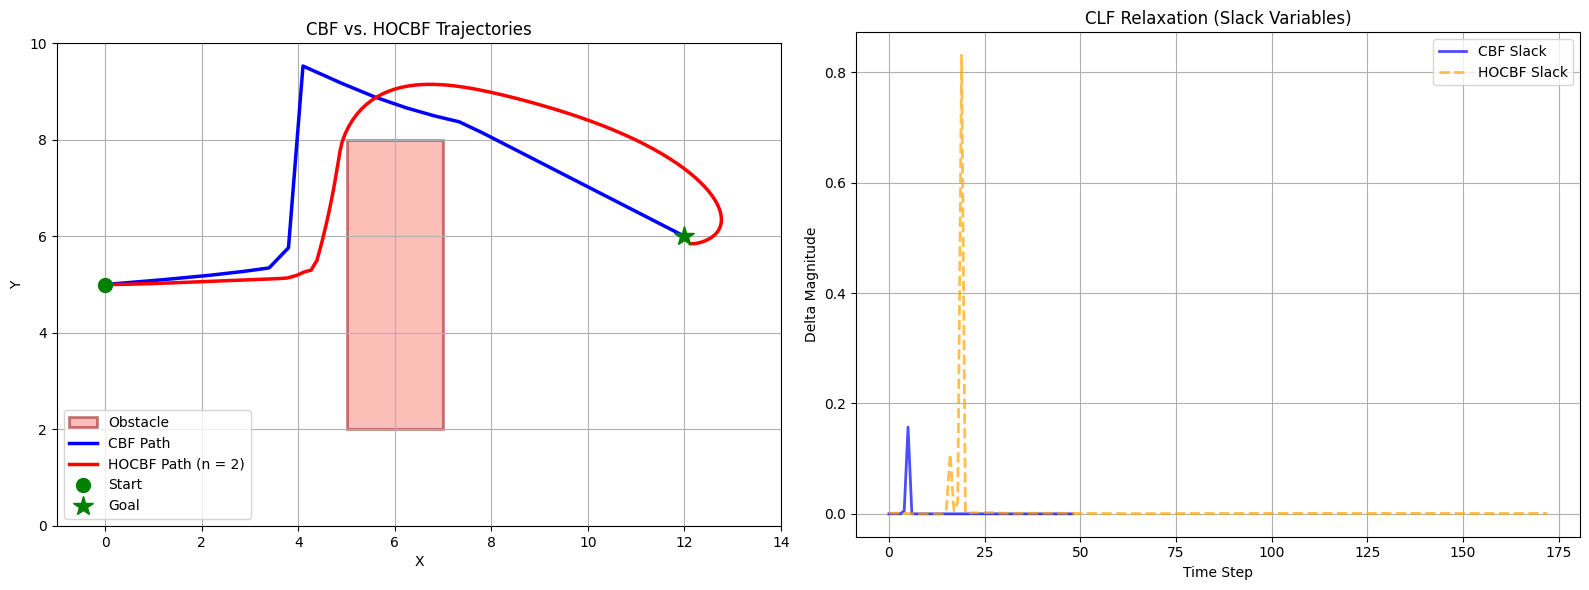

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from cvxopt import matrix, solvers
import scipy.linalg

# Turn off CVXOPT solver verbose output
solvers.options['show_progress'] = False

# ==========================================
# --- 1. PLAIN CBF (SINGLE INTEGRATOR) ---
# ==========================================

def get_smooth_rectangle_barrier(robot_pos, rect_config, rho=20.0):
    x, y = robot_pos
    x_min, x_max = rect_config['x_min'], rect_config['x_max']
    y_min, y_max = rect_config['y_min'], rect_config['y_max']

    h1 = x - x_max      
    h2 = x_min - x      
    h3 = y - y_max      
    h4 = y_min - y      
    
    h_vals = np.array([h1, h2, h3, h4])
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    normals = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
    weights = exps / sum_exps
    
    grad_h = np.zeros(2)
    for i in range(4):
        grad_h += weights[i] * normals[i]
        
    return h_val, grad_h

class CLFCBF_Rect_Controller:
    def __init__(self, rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.gamma = gamma
        self.alpha = alpha
        self.clf_penalty = clf_penalty
        self.prev_u = np.array([1.0, 0.0]) 

    def get_control(self, robot_state):
        x = robot_state
        Kp = 2.0
        u_ref = Kp * (self.goal_pos - x)
        
        h, grad_h = get_smooth_rectangle_barrier(x, self.rect_config, rho=20.0)
        
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        norm_u_ref = u_ref / (np.linalg.norm(u_ref) + 1e-6)
        dot_product = np.dot(norm_u_ref, norm_grad)
        
        if h < 0.5 and abs(dot_product) < 0.15:
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            if np.dot(tangent1, self.prev_u) > np.dot(tangent2, self.prev_u):
                u_ref = tangent1 * np.linalg.norm(u_ref)
            else:
                u_ref = tangent2 * np.linalg.norm(u_ref)
        
        diff_goal = x - self.goal_pos
        V = np.dot(diff_goal, diff_goal)
        grad_V = 2 * diff_goal

        P = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        q = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [grad_V[0], grad_V[1], -1.0],
            [-grad_h[0], -grad_h[1], 0.0]
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.alpha * V,
            self.gamma * h
        ]), tc='d')

        try:
            sol = solvers.qp(P, q, G, h_qp)
            z = np.array(sol['x']).flatten()
            u_opt = z[:2]
            self.prev_u = u_opt 
            return u_opt, z[2], h
        except ValueError:
            return np.array([0.0, 0.0]), 0.0, h


# ==========================================
# --- 2. HOCBF (DOUBLE INTEGRATOR) ---
# ==========================================

def get_smooth_rect_h_grad(p, config, rho=8.0):
    x, y = p
    h1 = x - config['x_max'] 
    h2 = config['x_min'] - x 
    h3 = y - config['y_max'] 
    h4 = config['y_min'] - y 
    h_vals = np.array([h1, h2, h3, h4])
    
    exps = np.exp(rho * h_vals)
    sum_exps = np.sum(exps)
    h_val = (1.0 / rho) * np.log(sum_exps)
    
    normals = np.array([[1,0], [-1,0], [0,1], [0,-1]])
    weights = exps / sum_exps
    grad_h = np.sum(weights[:, None] * normals, axis=0)
    
    return h_val, grad_h

def get_lqr_P_matrix():
    A = np.array([[0, 0, 1, 0], [0, 0, 0, 1], [0, 0, 0, 0], [0, 0, 0, 0]])
    B = np.array([[0, 0], [0, 0], [1, 0], [0, 1]])
    Q = np.eye(4) * 1.0  
    R = np.eye(2) * 1.0  
    
    P = scipy.linalg.solve_continuous_are(A, B, Q, R)
    return P, A, B

class HOCBF_CLF_Rect_Controller:
    def __init__(self, rect_config, goal_pos):
        self.rect_config = rect_config
        self.goal_pos = np.array(goal_pos)
        self.P, self.A, self.B = get_lqr_P_matrix()
        
        self.clf_rate = 1.0       
        self.clf_penalty = 400.0  
        self.hocbf_alpha1 = 5.0   
        self.hocbf_alpha2 = 5.0   
        
    def get_control(self, state):
        p = state[:2]
        v = state[2:]
        
        h, grad_h = get_smooth_rect_h_grad(p, self.rect_config, rho=8.0) 
        h_dot = np.dot(grad_h, v)

        norm_v = v / (np.linalg.norm(v) + 1e-6)
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        
        if h < 1.0 and np.dot(norm_v, norm_grad) < 0.2:
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            slide_dir = tangent1 if np.dot(tangent1, norm_v) > np.dot(tangent2, norm_v) else tangent2
            u_ref = 5.0 * slide_dir 
        else:
            u_ref = np.zeros(2)

        e = np.hstack((p - self.goal_pos, v))
        V = e.dot(self.P).dot(e)
        grad_V_e = 2 * e.dot(self.P)
        Lf_V = grad_V_e.dot(self.A).dot(e)
        Lg_V = grad_V_e.dot(self.B)

        dt_fake = 0.001
        p_lookahead = p + v * dt_fake
        _, grad_h_next = get_smooth_rect_h_grad(p_lookahead, self.rect_config)
        grad_h_dot_approx = (grad_h_next - grad_h) / dt_fake
        
        psi1 = h_dot + self.hocbf_alpha1 * h
        Lf_psi = np.dot(grad_h_dot_approx, v) + self.hocbf_alpha1 * h_dot
        Lg_psi = grad_h
        
        P_qp = matrix(np.diag([1.0, 1.0, self.clf_penalty]), tc='d')
        q_qp = matrix(np.array([-u_ref[0], -u_ref[1], 0.0]), tc='d')
        
        G = matrix(np.array([
            [Lg_V[0], Lg_V[1], -1.0],      
            [-Lg_psi[0], -Lg_psi[1], 0.0]  
        ]), tc='d')
        
        h_qp = matrix(np.array([
            -self.clf_rate * V - Lf_V,                     
            Lf_psi + self.hocbf_alpha2 * psi1              
        ]), tc='d')

        try:
            sol = solvers.qp(P_qp, q_qp, G, h_qp)
            z = np.array(sol['x']).flatten()
            return z[:2], z[2], V
        except ValueError:
            return -3.0 * v, 0.0, V


# ==========================================
# --- 3. COMBINED SIMULATION & PLOTTING ---
# ==========================================

def run_combined_simulation():
    # Setup Shared Scenario
    start_pos = np.array([0.0, 5.0])
    goal_pos = np.array([12.0, 6.0])
    rect_config = {'x_min': 5.0, 'x_max': 7.0, 'y_min': 2.0, 'y_max': 8.0}
    dt = 0.05
    steps = 400
    
    # --- RUN CBF ---
    cbf_controller = CLFCBF_Rect_Controller(rect_config, goal_pos, gamma=5.0, alpha=2.0, clf_penalty=1000.0)
    state_cbf = start_pos.copy()
    traj_cbf = [state_cbf.copy()]
    slack_cbf = []
    
    print("Running CLF-CBF-QP (Single Integrator)...")
    for i in range(steps):
        u_safe, slack, _ = cbf_controller.get_control(state_cbf)
        state_cbf = state_cbf + u_safe * dt
        traj_cbf.append(state_cbf.copy())
        slack_cbf.append(slack)
        if np.linalg.norm(state_cbf - goal_pos) < 0.1:
            print(f"CBF Goal Reached at step {i}!")
            break

    # --- RUN HOCBF ---
    hocbf_controller = HOCBF_CLF_Rect_Controller(rect_config, goal_pos)
    state_hocbf = np.array([0.0, 5.0, 4.0, 0.0]) # Includes high initial velocity
    traj_hocbf = [state_hocbf[:2].copy()]
    slack_hocbf = []
    
    print("Running HOCBF-CLF-QP (Double Integrator)...")
    for i in range(steps):
        u_safe, slack, _ = hocbf_controller.get_control(state_hocbf)
        state_hocbf[:2] += state_hocbf[2:] * dt + 0.5 * u_safe * dt**2
        state_hocbf[2:] += u_safe * dt
        traj_hocbf.append(state_hocbf[:2].copy())
        slack_hocbf.append(slack)
        if np.linalg.norm(state_hocbf[:2] - goal_pos) < 0.2 and np.linalg.norm(state_hocbf[2:]) < 0.5:
            print(f"HOCBF Goal Reached at step {i}!")
            break

    # --- VISUALIZATION ---
    traj_cbf = np.array(traj_cbf)
    traj_hocbf = np.array(traj_hocbf)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Combined Trajectories
    width = rect_config['x_max'] - rect_config['x_min']
    height = rect_config['y_max'] - rect_config['y_min']
    rect_patch = patches.Rectangle(
        (rect_config['x_min'], rect_config['y_min']), width, height, 
        linewidth=2, edgecolor='darkred', facecolor='salmon', alpha=0.5, label='Obstacle'
    )
    ax1.add_patch(rect_patch)
    
    ax1.plot(traj_cbf[:, 0], traj_cbf[:, 1], 'b-', linewidth=2.5, label='CBF Path')
    ax1.plot(traj_hocbf[:, 0], traj_hocbf[:, 1], 'red', linewidth=2.5, linestyle='-', label='HOCBF Path (n = 2)')
    
    ax1.plot(start_pos[0], start_pos[1], 'go', markersize=10, label='Start')
    ax1.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
    
    ax1.set_aspect('equal')
    ax1.set_xlim(-1, 14)
    ax1.set_ylim(0, 10)
    ax1.legend(loc='lower left')
    ax1.grid(True)
    ax1.set_title("CBF vs. HOCBF Trajectories")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")

    # Plot 2: Combined Slacks
    ax2.plot(slack_cbf, 'b-', alpha=0.7, linewidth=2, label='CBF Slack')
    ax2.plot(slack_hocbf, 'orange', alpha=0.7, linewidth=2, linestyle='--', label='HOCBF Slack')
    ax2.set_title("CLF Relaxation (Slack Variables)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Delta Magnitude")
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Execute the combined simulation
if __name__ == "__main__":
    run_combined_simulation()